In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from augur.utils import json_to_tree
from Bio import Phylo, SeqIO

import baltic as bt

In [2]:
def trees_to_baltic(virus):

    nextstrainPath= f'../nextstrain_builds/egg-enriched/auspice/{virus}_ha_egg.json'
    json_translation={'absoluteTime':lambda k: k.traits['node_attrs']['num_date']['value'],
                      'name':'name'}
    tree, metadata = bt.loadJSON(nextstrainPath,json_translation=json_translation)
    
    return tree

In [3]:
def get_strain_passage_type(virus):
    """
    Get the names of the egg-passaged strains
    """
    
    tree_path= f'../nextstrain_builds/egg-enriched/auspice/{virus}_ha_egg.json'
    
    #read in the tree
    with open(tree_path, 'r') as f:
        tree_json = json.load(f)
        
    #put tree in Bio.phylo format
    tree = json_to_tree(tree_json)
    
    name_to_passage = {}
    
    for node in tree.find_clades(terminal=True):
        name_to_passage[node.name] = node.node_attrs['passage_category']['value']
        
    name_to_passage[tree.root.name] = 'unpassaged'

    
    return name_to_passage

In [4]:
cmap = {'h3n2': '#6C3BAA', 'h1n1pdm': '#088F8F', 
        'vic': '#FF4500', 'yam': '#fbba0a'}

In [5]:
edge_cmap = {'h3n2': '#59318d', 'h1n1pdm': '#0189e0', 
        'vic': '#b33000', 'yam': '#D6A650'}

In [6]:
def make_passage_cmap(virus):
    
    tree_path= f'../nextstrain_builds/egg-enriched/auspice/{virus}_ha_egg.json'
    
    #read in the tree
    with open(tree_path, 'r') as f:
        tree_json = json.load(f)
        
    #put tree in Bio.phylo format
    tree = json_to_tree(tree_json)
    
    color_map = {}
    
    for node in tree.find_clades():
        if 'passage_category' in node.node_attrs.keys():
            passage = node.node_attrs['passage_category']['value']
            if passage=='egg':
                color_map[node.name] = cmap[virus]
            else:
                color_map[node.name] = '#d3d3d3'
        else:
            color_map[node.name] = '#d3d3d3'
    
    
    return color_map

In [7]:
def plot_tree(virus, ax):
    """
    Draw the tree for each virus using baltic
    """

    branchWidth=0.8

    
    tree = trees_to_baltic(virus)
    
    name_to_passage = get_strain_passage_type(virus)
    
    color_map = make_passage_cmap(virus)
    
        
    if virus == 'h3n2':
        branch_color = '#808080'
    else:
        branch_color = '#9d9d9d'


    # k objects are tips, nodes, branches
    for k in tree.Objects: ## iterate over objects in tree
        y=k.y ## or use absolute time instead
        x=k.absoluteTime
        node_name = k.name


        if x==None: ## matplotlib won't plot Nones, like root
            x=0.0
        if 'node_attrs' in k.parent.traits:
            xp=k.parent.absoluteTime ## get x position of current object's parent
        else:
            xp = x

        if isinstance(k,bt.leaf) or k.branchType=='leaf': ## if leaf...
            m = "."
            passage = name_to_passage[node_name] ## get passage category for tips only
            if passage == 'egg':
                if virus =='h3n2':
                    tipSize = 40
                else:
                    tipSize= 15
                ax.scatter(x,y, s=tipSize, facecolor=cmap[virus], edgecolor=edge_cmap[virus], 
                           linewidth=0.5, marker=m, zorder=3) ## plot circle for every tip
            else:
                if virus == 'h3n2':
                    tipSize = 20
                else:
                    tipSize = 15
                fc = '#d3d3d3'
                ec = '#808080'
                ax.scatter(x,y, s=tipSize, facecolor=fc, edgecolor = ec, 
                           linewidth=0.5, marker=m, zorder=2) ## plot circle for every tip
        
        #plot the vertical lines
        elif isinstance(k,bt.node) or k.branchType=='node': ## if node...
            ax.plot([x,x],[k.children[-1].y, k.children[0].y], lw=branchWidth, color=branch_color, ls='-',zorder=1) 
        
        #plot the branches
        ax.plot([xp,x],[y,y],lw=branchWidth,color=branch_color,ls='-',zorder=1)


    ax.spines['left'].set_color('white')
    ax.spines['top'].set_color('white')
    ax.spines['right'].set_color('white')
    ax.tick_params(axis='x', labelsize=12)
    ax.set_yticks([])
    if virus=='h1n1pdm':
        ax.set_xticks([2009,2024])
    elif virus in ['vic', 'yam']:
        ax.set_xticks([1994, 2009, 2024])
    
    return ax



In [8]:
def get_subtree_nodes(virus, internal_node):
    """
    Given an internal node name, get the subtree descending from that node
    """
    
    tree_path= f'../nextstrain_builds/egg-enriched/auspice/{virus}_ha_egg.json'
    
    #read in the tree
    with open(tree_path, 'r') as f:
        tree_json = json.load(f)
        
    #put tree in Bio.phylo format
    tree = json_to_tree(tree_json)
    
    subtree_nodes = []
    
    for node in tree.find_clades():
        if node.name == internal_node:
            subtree_nodes+=[x.name for x in node.get_nonterminals()]
            subtree_nodes+=[x.name for x in node.get_terminals()]
            
    return subtree_nodes

In [9]:
def get_muts_on_branch(virus, list_of_egg_strains):
    """
    Return all aa muts for each terminal branch leading to egg-passaged strain and each 
    internal branch in egg-only cluster (specified by internal_branches_to_label)
    """
    
    tree_path= f'../nextstrain_builds/egg-enriched/auspice/{virus}_ha_egg.json'

    #read in the tree
    with open(tree_path, 'r') as f:
        tree_json = json.load(f)

    #put tree in Bio.phylo format
    tree = json_to_tree(tree_json)
                       
    muts_by_branch = {}

    for node in tree.find_clades():
        if node.name in list_of_egg_strains:
            ha1_muts = node.branch_attrs['mutations'].get('HA1', '')
            ha2_muts = node.branch_attrs['mutations'].get('HA2', '')

            # format muts to print on tree
            format_muts = ''
            if len(ha1_muts)!=0 and len(ha2_muts)!=0:
                format_muts = ", ".join(ha1_muts) + " HA2: " + ", ".join(ha2_muts)
            elif len(ha1_muts)!=0:
                format_muts = ", ".join(ha1_muts)
            elif len(ha2_muts)!=0:
                format_muts = "HA2: "+ ", ".join(ha2_muts)
            muts_by_branch[node.name] = format_muts
                       
    return muts_by_branch

In [10]:
def plot_treezoom(ax, virus = 'h3n2', internal_node='NODE_0012177'):
    """
    Draw a zoomed portion of the H3N2 tree starting from the specified internal node, using baltic
    
    """

    branchWidth=3

    
    tree = trees_to_baltic(virus)
    
    # get passage type for each tip
    name_to_passage = get_strain_passage_type(virus)
    
    # get subtree starting at specified internal node
    subtree_nodes = get_subtree_nodes(virus, internal_node)
    # don't need to plot ALL of this subtree because there's a clade of a bunch of contextual sequences that aren't needed
    to_exclude = get_subtree_nodes(virus, 'NODE_0011128')

    # subtract these from the list of nodes to plot
    subtree_nodes = [x for x in subtree_nodes if x not in to_exclude]
    subtree_nodes+=['NODE_0011128']


    branch_color = '#808080'
    
    # list all egg strains 
    list_of_egg_strains = ['A/Newcastle/104/2018-egg', 'A/Newcastle/83/2018-egg', 'A/Austria/1108601/2018-egg', 
                           'A/Newcastle/82/2018-egg', 'A/SouthAustralia/39/2019-egg']

    # get all aa mutations on these branches
    muts_by_branch = get_muts_on_branch(virus, list_of_egg_strains)
    
    # manually adjust positions of tips and branches to squish non-egg clades
    # and store their positions
    squish_clade = {'NODE_0011124': -0.5,'NODE_0011125': -0.5,'NODE_0011126': -0.5,'NODE_0011127': -0.5,
                    'A/Singapore/GP2153/2019': -0.5,'A/Singapore/NUH0026/2019':-0.5,'A/RioGrandedoSul/306/2019': -0.5,
                    'A/Netherlands/10127/2019': -0.5,'A/Newcastle/83/2018': -0.75, 
                    'NODE_0011095': -0.75, 'NODE_0011098': -0.75, 'NODE_0011099': -0.5, 'NODE_0011096': -0.75,
                    'NODE_0003391': -0.85, 'A/Vietnam/236/2018': -0.25, 'A/Austria/1108601/2018-egg': -0.9, 
                    'A/Austria/1108601/2018': -0.85, 'A/Newcastle/83/2018-egg': -0.75, 'A/Victoria/753/2018': -0.5, 
                    'A/Vietnam/245/2018':- 0.5}
    
    manual_adjustments = {'A/Newcastle/82/2018-egg': -0.75, 'A/Newcastle/104/2018-egg':0.25, 'A/Newcastle/606/2019': 0.25,
                          'A/Townsville/1005/2018': 1.0, 'A/SouthAustralia/39/2019-egg': 0.25, 'A/SouthAustralia/39/2019': -0.25,
                          'NODE_0011128': 1.5, **squish_clade}
    
    
    adjusted_ys = {}
    for k in tree.Objects: 
        node_name = k.name
        
        if node_name in subtree_nodes:
            if node_name in manual_adjustments:
                adjusted_ys[node_name] = k.y + manual_adjustments[node_name]
            else:
                adjusted_ys[node_name] = k.y 

    
    # points to label for figure
    label_tips = {'A/SouthAustralia/39/2019-egg': '1', 'A/Newcastle/83/2018-egg': '2', 
                   'A/Newcastle/82/2018-egg': '3'}
    label_tips_ypos = {'A/SouthAustralia/39/2019-egg': -0.6, 'A/Newcastle/83/2018-egg': -0.4, 
                   'A/Newcastle/82/2018-egg': -0.6}
    label_tips_xpos = {'A/SouthAustralia/39/2019-egg': 0.12, 'A/Newcastle/83/2018-egg': 0.12, 
                   'A/Newcastle/82/2018-egg': 0.12}
    
    
    # k objects are tips, nodes, branches
    for k in tree.Objects: ## iterate over objects in tree

        x=k.absoluteTime
        node_name = k.name
        

        
        if x==None: ## matplotlib won't plot Nones, like root
            x=0.0
        if 'node_attrs' in k.parent.traits:
            xp=k.parent.absoluteTime ## get x position of current object's parent
        else:
            xp = x
        
        if node_name in subtree_nodes:
            
            y= adjusted_ys[node_name]
            
            # if this is the start of the clade that isn't getting plotted, draw a triangle
            if node_name == 'NODE_0011128':
                ax.scatter(x,y, s=500, facecolor=branch_color, marker='<', zorder=3)
                ax.plot([xp,x],[y,y],lw=branchWidth,color=branch_color,ls='-',zorder=1)
                
            else:
                # if tip
                if isinstance(k,bt.leaf) or k.branchType=='leaf':
                    passage = name_to_passage[node_name] ## get passage category for tips only
                    if passage=='egg':
                        # call out the paired strain with square tip label instead of circle
                        if node_name == 'A/SouthAustralia/39/2019-egg':
                            ax.scatter(x,y, s=200, facecolor=cmap[virus], edgecolor=edge_cmap[virus], 
                                   linewidth=0.5, marker='s', zorder=3)
                        else:
                            ax.scatter(x,y, s=400, facecolor=cmap[virus], edgecolor=edge_cmap[virus], 
                                       linewidth=0.5, marker='.', zorder=3)
                        ax.plot([xp,x],[y,y],lw=branchWidth,color=edge_cmap[virus],ls='-',zorder=1)
                        
                        # label tips to call out in figure
                        if node_name in label_tips:
                            ax.text(x+label_tips_xpos[node_name], y+label_tips_ypos[node_name]-0.06, label_tips[node_name], 
                                    color=cmap[virus], fontsize=16)
                            circle = mpatches.Ellipse((x+label_tips_xpos[node_name]+0.03, y+label_tips_ypos[node_name]+0.3), 
                                                      width=0.15, height=1.5, edgecolor=cmap[virus], facecolor='none', linewidth=2)
                            ax.add_patch(circle)
                            
                    else:
                        # call out the paired strain with square tip label instead of circle
                        if node_name == 'A/SouthAustralia/39/2019':
                            ax.scatter(x,y, s=200, facecolor='#d3d3d3', edgecolor='#808080', 
                                   linewidth=0.5, marker='s', zorder=3)
                        else:
                            ax.scatter(x,y, s=400, facecolor='#d3d3d3', edgecolor='#808080', 
                                       linewidth=0.5, marker='.', zorder=3)
                        ax.plot([xp,x],[y,y],lw=branchWidth,color=branch_color,ls='-',zorder=1)

                
                elif isinstance(k,bt.node) or k.branchType=='node': ## if node...
                    #plot the vertical lines
                    ax.plot([x,x],[adjusted_ys[k.children[-1].name], adjusted_ys[k.children[0].name]], lw=branchWidth, color=branch_color, ls='-',zorder=1) 

                    #plot the branches
                    ax.plot([xp,x],[y,y],lw=branchWidth,color=branch_color,ls='-',zorder=1)
                
                # label muts on egg branches
                if node_name in list_of_egg_strains:
                    x_pos = xp+ 0.03
                    if node_name == 'A/Newcastle/83/2018-egg':
                        ax.text(x_pos-0.2, y+0.6, muts_by_branch[node_name], fontsize=12)
                    elif node_name == 'A/Newcastle/82/2018-egg':
                        ax.text(x_pos, y+0.7, muts_by_branch[node_name], fontsize=12)
                    elif node_name == 'A/SouthAustralia/39/2019-egg':
                        ax.text(x_pos, y+0.8, muts_by_branch[node_name], fontsize=12)
                    else:
                        ax.text(x_pos, y+0.6, muts_by_branch[node_name], fontsize=12)
                    



    ax.spines['left'].set_color('white')
    ax.spines['top'].set_color('white')
    ax.spines['right'].set_color('white')
    ax.tick_params(axis='x', labelsize=14)
    ax.set_yticks([])
    ax.spines['bottom'].set_color('white')
    ax.set_xticks([])

        
    return ax


In [11]:
def make_hist_of_egg_passaged(virus, ax):
    """
    Show how many egg-passaged strains, compared to non-egg-passaged over time
    """
    
    tree_path= f'../nextstrain_builds/egg-enriched/auspice/{virus}_ha_egg.json'
    
    #read in the tree
    with open(tree_path, 'r') as f:
        tree_json = json.load(f)
        
    #put tree in Bio.phylo format
    tree = json_to_tree(tree_json)
    
    passage_by_time = []
    
    for node in tree.find_clades(terminal=True):
        passage = node.node_attrs['passage_category']['value']
        date = node.node_attrs['num_date']['value']
        year = int(str(date)[:4])
        if passage == 'egg':
            passage_by_time.append({'strain': node.name, 'passage': 'egg', 'date': date, 'year': year})
        else:
            passage_by_time.append({'strain': node.name, 'passage': 'other', 'date': date, 'year': year})
        
    df = pd.DataFrame(passage_by_time)
    
#     years = list(df.year.unique())
    # force longer time period to match tree axis (including branch to common ancestor)
    years = list(range(1990, 2026))
    
    year_proportions = []
    for y in years:
        if y in df.year.unique():
            y_egg = len(df[(df.year==y) & (df.passage=='egg')])
            y_other = len(df[(df.year==y) & (df.passage=='other')])
            year_proportions.append({'year': y, 'egg_proportion': y_egg/(y_egg+y_other), 'egg_count': y_egg})
        else:
            year_proportions.append({'year': y, 'egg_proportion': 0.0, 'egg_count': 0})
            
    
    proportions_df = pd.DataFrame(year_proportions)
    
    sns.barplot(data=proportions_df, x='year', y='egg_proportion', color=cmap[virus], ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('Proportion\negg-passaged', fontsize=12)
    ax.tick_params(axis='x', labelsize=10, rotation=90)
    ax.tick_params(axis='y', labelsize=12)
    
    sns.despine()
    
    return ax
                 

In [12]:
# w_pair_cmap = {'h3n2': '#fbba0a', 'h1n1pdm': '#FF4500', 'vic': '#088F8F', 'yam':'#45b6fe'}
# wo_pair_cmap = {'h3n2': '#fde39d', 'h1n1pdm': '#ffa27f', 'vic': '#83c7c7', 'yam':'#a2dafe'}

In [13]:
w_pair_cmap = {'h3n2': '#6C3BAA', 'h1n1pdm': '#45b6fe', 'vic': '#FF4500', 'yam': '#fbba0a'}
wo_pair_cmap = {'h3n2': '#a986d5', 'h1n1pdm': '#a2dafe', 'vic': '#ffa27f', 'yam':'#fde39d'}

In [14]:
def count_paired_sequences(virus, segment= 'ha'):
    """
    Find how many egg-passaged sequences have a paired non-egg-passaged sequence
    """
    
    tree_file = f'../nextstrain_builds/egg-enriched/auspice/{virus}_{segment.lower()}_egg.json'

    with open(tree_file) as json_handle:
        tree_json = json.load(json_handle)

    tree = json_to_tree(tree_json)
    
    num_egg_seqs = 0
    egg_seq_names = []
    
    for node in tree.find_clades(terminal=True):
        if node.node_attrs['passage_category']['value']=='egg':
            num_egg_seqs+=1
            egg_seq_names.append(node.name)
            
    potential_pair_names = [x.strip('-egg') for x in egg_seq_names]
    num_egg_seqs_w_pair = 0
    
    for node in tree.find_clades(terminal=True):
        if node.node_attrs['passage_category']['value']!='egg':
            if node.name in potential_pair_names:
                num_egg_seqs_w_pair+=1
    
    return num_egg_seqs, num_egg_seqs_w_pair
            

In [15]:
def plot_num_egg_seqs_w_pair(ax, filename=None):
    """
    plot the total number of egg sequences and show the number that have a non-egg-passaged pair
    """
    viruses = ['h3n2', 'h1n1pdm', 'vic', 'yam']
    
    egg_seqs_w_pair = []
    egg_seqs_wo_pair = []
    
    to_plot = []
    
    for v in viruses:
        num_egg_seqs, num_egg_seqs_w_pair = count_paired_sequences(v)
        egg_seqs_w_pair.append(num_egg_seqs_w_pair)
        egg_seqs_wo_pair.append(num_egg_seqs-num_egg_seqs_w_pair)
        to_plot.append({'virus': v, 'total': num_egg_seqs, 
                        'w_pair': num_egg_seqs_w_pair, 'wo_pair': num_egg_seqs-num_egg_seqs_w_pair})
#         to_plot.append({'virus': v, 'count': num_egg_seqs-num_egg_seqs_w_pair, 'category': 'w0_pair'})
    
    capitalized_names = {'h3n2': 'H3N2', 'h1n1pdm': 'H1N1pdm', 'vic': 'Vic', 'yam': 'Yam'}
    
    df = pd.DataFrame(to_plot)
    
    for i, row in df.iterrows():
        color_wpair = w_pair_cmap[row['virus']]
        color_wopair = wo_pair_cmap[row['virus']]
        pct_w_pair = round((row['w_pair']/row['total'])*100)
        pct_label = f'{pct_w_pair} %'
        rects1 = ax.bar(capitalized_names[row['virus']], row['w_pair'],  color=color_wpair)
        rects2 = ax.bar(capitalized_names[row['virus']], row['wo_pair'], 
                        bottom=row['w_pair'], color=color_wopair, label=pct_label)
        ax.bar_label(rects2, [str(pct_label)], fontsize=12, padding=3)

    
    ax.set_ylabel('Number of\negg-passaged strains', fontsize=12)
    ax.tick_params(axis='both', labelsize=14)
    ax.set_yticks([0,800,1600])
    
    dark_patch = mpatches.Patch(color='#737373', label='Pair')
    light_patch = mpatches.Patch(color='#d3d3d3', label='No pair')
    ax.legend(handles=[dark_patch, light_patch], bbox_to_anchor=(1.0, 1.1), 
              bbox_transform=ax.transAxes, fontsize=12)
    
    sns.despine()
    
    return ax

In [16]:
def get_num_seqs(virus, segment='ha'):
    """
    Retrun the number of egg-passaged and the number of other seqs
    """
    
    tree_file = f'../nextstrain_builds/egg-enriched/auspice/{virus}_{segment}_egg.json'

    with open(tree_file) as json_handle:
        tree_json = json.load(json_handle)

    tree = json_to_tree(tree_json)
    
    num_egg_seqs = 0
    num_other = 0
    
    for node in tree.find_clades(terminal=True):
        if node.node_attrs['passage_category']['value']=='egg':
            num_egg_seqs+=1
        else:
            num_other+=1
    
    return num_egg_seqs, num_other

In [17]:
def example_tip_table(ax):
    """
    For 3 exmample tips, make a table that lists their mutations
    and whether or not the egg-passaged sequence has a direct pair
    """
    
    muts_data = [
        ["1", "Yes", "T160K, L194P"],
        ["2", "No", "T160K, L194P"],
        ["3", "No", "H156Q, T160K, G186V"]
    ]

    # Column headers
    columns = ["Strain", "Pair?", "Inferred egg-passaging mutations"]

    ax.set_axis_off()
        
    # Create table
    table = ax.table(cellText=muts_data, colLabels=columns, cellLoc="center", loc="center")

    # Add only the bottom border for the header row
    for i in range(len(muts_data) + 1):  # +1 to include headers
        for j in range(len(columns)):
            cell = table[i, j]
            if i ==0:
                cell.visible_edges = "B"
                cell.set_linewidth(1)
                cell.set_edgecolor('black')
            # need to turn on top edge of first non-header row too
            if i ==1:
                cell.visible_edges = "T"
                cell.set_linewidth(1)
                cell.set_edgecolor('black')
            else:
                cell.set_linewidth(0)
            
            cell.set_facecolor("#ddcfee")
                
    # Draw background rectangle to match the table's exact size
    plt.draw()  # Ensures the table layout is computed
    bbox = table.get_window_extent(ax.figure.canvas.get_renderer())
    bbox = bbox.transformed(ax.transData.inverted())  # Convert from figure to Axes coordinates

    rect = plt.Rectangle((bbox.x0, bbox.y0), bbox.width, bbox.height, 
                         color="#ddcfee", zorder=-1, transform=ax.transData, clip_on=False)
    ax.add_patch(rect)
            

    # Adjust font size and cell size
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.auto_set_column_width([0, 1, 2])  # Adjust column width

    return ax

In [18]:
def plot_fig1(filename=False):
    """
    
    """
    
    sns.set_style("white")
    plt.rcParams['font.family'] = 'Arial'
    
    fig = plt.figure(figsize=(14, 10))
    # need a blank row for x-labels under histogram
    gs = GridSpec(8, 4, width_ratios=[1,1,1,2], height_ratios=[2,0.25,2, 0.25, 0.75, 0.5,1,1])

    
    # plot large h3n2 tree
    ax1 = fig.add_subplot(gs[0:3, 0:3])
    ax1.text(-0.08, 1.0, 'A', fontsize=20, transform=ax1.transAxes)
    plot_tree('h3n2', ax1)
    ax1.text(0.85, 0.95, 'A/H3N2', fontsize=20, transform=ax1.transAxes, ha='right')
    # print total num egg seqs and contextual seqs
    num_egg_h3n2, num_other_h3n2 = get_num_seqs('h3n2')
    h3n2_color = cmap['h3n2']
    ax1.text(-0.02, 0.13, 'Egg:', fontsize=14, color='#808080', transform=ax1.transAxes)
    ax1.text(0.04, 0.13, f'{num_egg_h3n2}', fontsize=14, color=f'{h3n2_color}', transform=ax1.transAxes)
    ax1.text(-0.02, 0.05, f'Context:', fontsize=14, color=f'#808080', transform=ax1.transAxes)
    ax1.text(0.09, 0.05, f'{num_other_h3n2}', fontsize=14, color=f'#6c6c6c', transform=ax1.transAxes)
    

    
    # plot historgram
    ax2 = fig.add_subplot(gs[4, 0:3])
    make_hist_of_egg_passaged('h3n2', ax2)
    
    
    # plot h1n1pdm tree
    ax3 = fig.add_subplot(gs[6:8, 0])
    ax3.text(-0.2, 0.98, 'B', fontsize=20, transform=ax3.transAxes)
    plot_tree('h1n1pdm', ax3)
    ax3.text(1.0, 0.95, 'A/H1N1pdm', fontsize=16, transform=ax3.transAxes, ha='right')
    num_egg_h1n1pdm, num_other_h1n1pdm = get_num_seqs('h1n1pdm')
    h1n1pdm_color = cmap['h1n1pdm']
    ax3.text(-0.04, 0.12, 'Egg:', fontsize=13, color='#808080', transform=ax3.transAxes)
    ax3.text(0.17, 0.12, f'{num_egg_h1n1pdm}', fontsize=13, color=f'{h1n1pdm_color}', transform=ax3.transAxes)
    ax3.text(-0.04, 0.02, f'Context:', fontsize=13, color=f'#808080', transform=ax3.transAxes)
    ax3.text(0.32, 0.02, f'{num_other_h1n1pdm}', fontsize=13, color=f'#6c6c6c', transform=ax3.transAxes)

    
    # plot vic tree
    ax4 = fig.add_subplot(gs[6:8, 1])
    ax4.text(-0.12, 0.98, 'C', fontsize=20, transform=ax4.transAxes)
    plot_tree('vic', ax4)
    ax4.text(1.0, 0.95, 'B/Vic', fontsize=16, transform=ax4.transAxes, ha='right')
    num_egg_vic, num_other_vic = get_num_seqs('vic')
    vic_color = cmap['vic']
    ax4.text(-0.04, 0.12, 'Egg:', fontsize=13, color='#808080', transform=ax4.transAxes)
    ax4.text(0.17, 0.12, f'{num_egg_vic}', fontsize=13, color=f'{vic_color}', transform=ax4.transAxes)
    ax4.text(-0.04, 0.02, f'Context:', fontsize=13, color=f'#808080', transform=ax4.transAxes)
    ax4.text(0.32, 0.02, f'{num_other_vic}', fontsize=13, color=f'#6c6c6c', transform=ax4.transAxes)

    
    # plot yam tree
    ax5 = fig.add_subplot(gs[6:8, 2])
    ax5.text(-0.12, 0.98, 'D', fontsize=20, transform=ax5.transAxes)
    plot_tree('yam', ax5)
    ax5.text(1.0, 0.95, 'B/Yam', fontsize=16, transform=ax5.transAxes, ha='right')
    num_egg_yam, num_other_yam = get_num_seqs('yam')
    yam_color = cmap['yam']
    ax5.text(-0.04, 0.12, 'Egg:', fontsize=13, color='#808080', transform=ax5.transAxes)
    ax5.text(0.19, 0.12, f'{num_egg_yam}', fontsize=13, color=f'{yam_color}', transform=ax5.transAxes)
    ax5.text(-0.04, 0.02, f'Context:', fontsize=13, color=f'#808080', transform=ax5.transAxes)
    ax5.text(0.32, 0.02, f'{num_other_yam}', fontsize=13, color=f'#6c6c6c', transform=ax5.transAxes)

    
    # plot number of strains with pair
    ax6 = fig.add_subplot(gs[0, 3])
    ax6.text(-0.25, 0.98, 'E', fontsize=20, transform=ax6.transAxes)
    plot_num_egg_seqs_w_pair(ax6)
    
    # spacer axis
    
    
    # plot h3n2 tree zoom
    ax7 = fig.add_subplot(gs[2:7, 3])
    ax7.text(-0.1, 0.93, 'F', fontsize=20, transform=ax7.transAxes)
    plot_treezoom(ax7)
    
    # plot table with tip muts
    ax8 = fig.add_subplot(gs[7, 3])
#     ax8.text(-0.1, 0.88, 'G', fontsize=20, transform=ax8.transAxes)
    example_tip_table(ax8)
    
    if filename:
        fig.savefig(filename, dpi=400, bbox_inches='tight', transparent=False, facecolor='white')


Tree height: 32.022000
Tree length: 4105.366000
annotations present

Numbers of objects in tree: 21904 (10457 nodes and 11447 leaves)


Tree height: 16.390000
Tree length: 4231.648000
annotations present

Numbers of objects in tree: 23090 (10818 nodes and 12272 leaves)


Tree height: 36.253000
Tree length: 6819.050000
annotations present

Numbers of objects in tree: 21957 (10259 nodes and 11698 leaves)


Tree height: 30.862000
Tree length: 5087.595000
annotations present

Numbers of objects in tree: 20189 (9410 nodes and 10779 leaves)


Tree height: 32.022000
Tree length: 4105.366000
annotations present

Numbers of objects in tree: 21904 (10457 nodes and 11447 leaves)



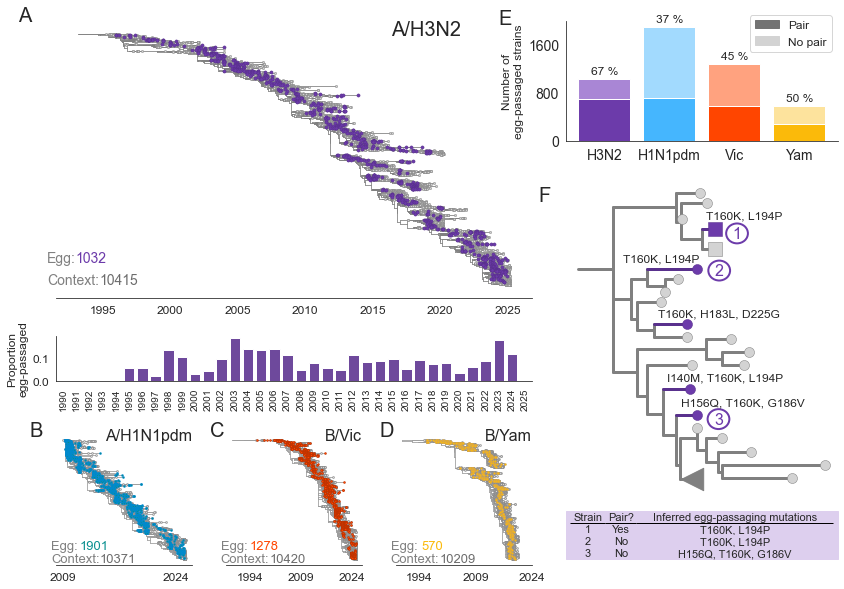

In [19]:
plot_fig1(filename = 'Figure1/Figure1.png')